In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#importing data
df = pd.read_csv('CocaCola_Sales_Rawdata.csv')

In [ ]:
# Preprocess the date column
df['Quarter'] = df['Quarter'].str.replace('Q', '')
df['Quarter'] = pd.to_datetime(df['Quarter'], format='%m_%y')

In [ ]:
df.set_index('Quarter', inplace=True)

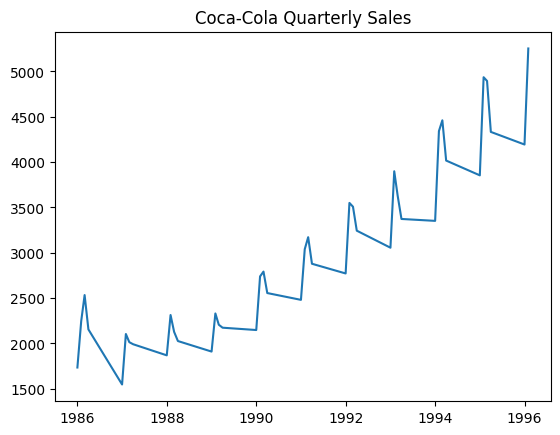

In [ ]:
# Plot the sales data
plt.plot(df['Sales'])
plt.title('Coca-Cola Quarterly Sales')
plt.show()

In [ ]:
# Check stationarity (using Dickey-Fuller test)
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Sales'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: 1.3094210180613548
p-value: 0.9966611674081021


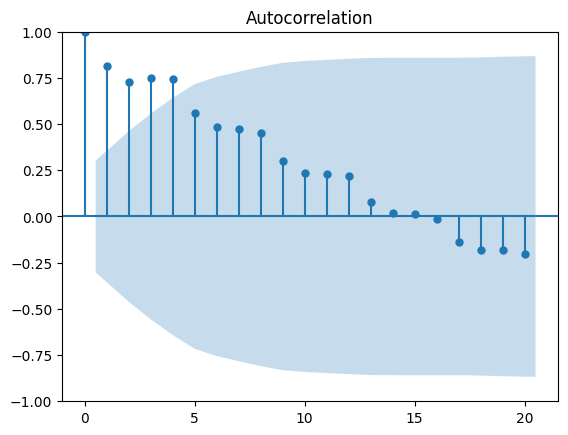

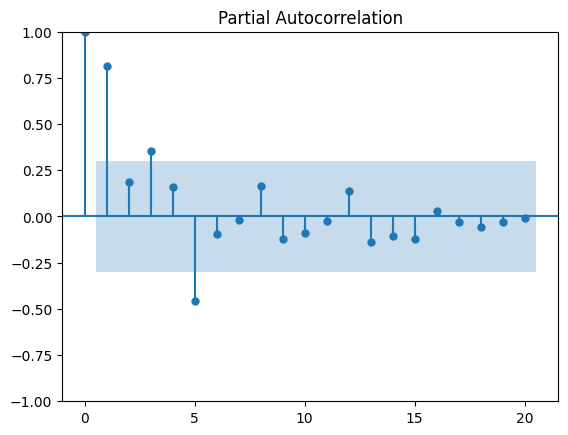

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['Sales'], lags=20)
plt.show()
plot_pacf(df['Sales'], lags=20)
plt.show()


In [ ]:
p, d, q = 5, 2, 3

In [ ]:
# Fit ARIMA model
from statsmodels.tsa.arima.model import ARIMA
order = (p, d, q)
model = ARIMA(df['Sales'], order=order)
model_fit = model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

In [ ]:
# Forecast using the fitted model
forecast_steps = 4
forecast = model_fit.forecast(steps=forecast_steps)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
# Calculate RMSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(df['Sales'][-forecast_steps:], forecast, squared=False)
print('Root Mean Squared Error (RMSE):', mse)

Root Mean Squared Error (RMSE): 340.0504295659175


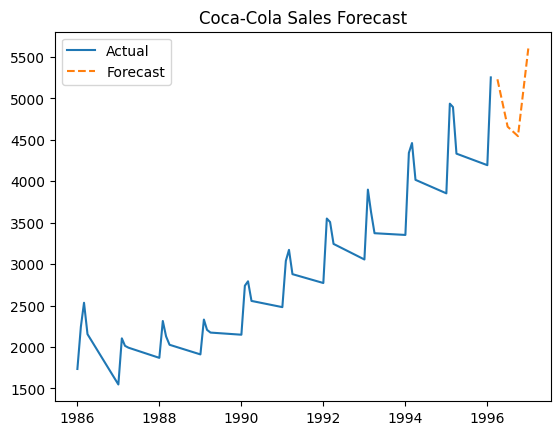

In [ ]:
# Plot actual vs forecasted values
plt.plot(df['Sales'].index, df['Sales'], label='Actual')
forecast_index = pd.date_range(start=df['Sales'].index[-1], periods=forecast_steps, freq='Q')
plt.plot(forecast_index, forecast, label='Forecast', linestyle='dashed')
plt.legend()
plt.title('Coca-Cola Sales Forecast')
plt.show()


In [ ]:
# Forecast future quarters
future_steps = 8
future_forecast = model_fit.forecast(steps=future_steps)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


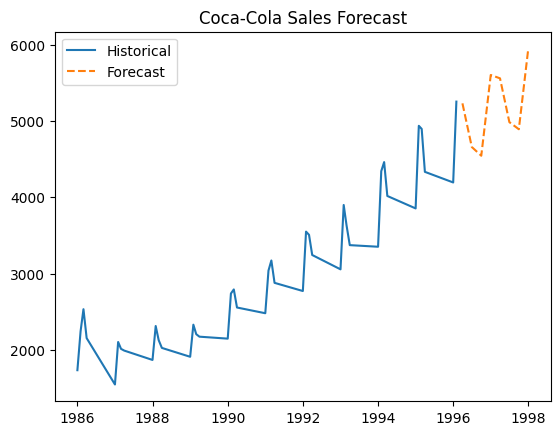

In [ ]:
# forecast plot
plt.plot(df['Sales'].index, df['Sales'], label='Historical')
future_index = pd.date_range(start=df['Sales'].index[-1] + pd.DateOffset(1), periods=future_steps, freq='Q')
plt.plot(future_index, future_forecast, label='Forecast', linestyle='dashed')
plt.legend()
plt.title('Coca-Cola Sales Forecast')
plt.show()